In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import time, os, sys
from tqdm import tqdm
from glob import glob
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from photutils.psf import fit_2dgaussian, GaussianPRF
from scipy.stats import multivariate_normal
from scipy.interpolate import make_smoothing_spline
from photutils.aperture import RectangularAperture

# from utils import *

%load_ext autoreload
%autoreload 2

In [59]:
fc = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/data/20251027_mono_cube_L_new.fits'
fl = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/Lnew_lams.fits'
fp = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/L_positions_new.fits'
fr = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/L_psf_fitting_results.fits'

cube = fits.getdata(fc) # (nlams, nx, ny)
lams = fits.getdata(fl) # (nlams)
pos = fits.getdata(fp) # (nlams, nx, ny, 6)  > [x_center, x_start, x_end, y_center, y_start, y_end]
res = fits.getdata(fr) # (8, nx, ny) > [x_cen, y_cen, x_fwhm, y_fwhm, theta, fwhm||, fwhm|_, quality_flags]

print(np.shape(lams))
print(np.shape(pos))
print(np.shape(res))
# plt.imshow(cube[10], origin='lower')
# plt.colorbar()

(56,)
(56, 103, 110, 6)
(56, 8, 103, 110)


(1000.0, 1250.0)

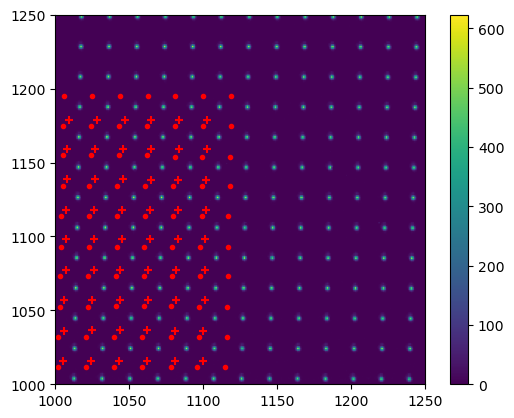

In [29]:
i = 20

plt.imshow(cube[i], origin='lower', vmin=0)
plt.colorbar()

plt.scatter(pos[i,50:60,50:60,1], pos[i,50:60,50:60,4], marker='+', color='r', )
plt.scatter(pos[i,50:60,50:60,2], pos[i,50:60,50:60,5], marker='.', color='r', )

plt.xlim(1000,1250)
plt.ylim(1000,1250)

(2048, 2048)


(1075.0, 1225.0)

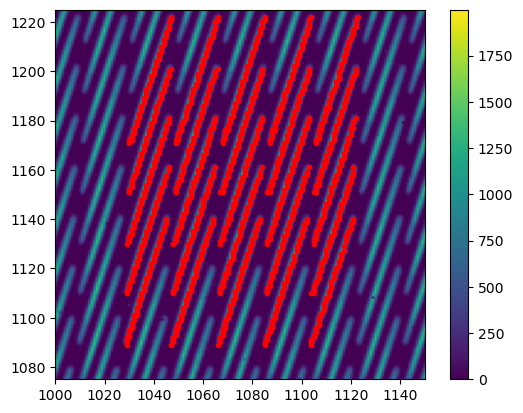

In [149]:
squish = np.sum(cube, axis=0)
print(np.shape(squish))

plt.imshow(squish, origin='lower', vmin=0)
plt.colorbar()

# plt.scatter(pos[0,:,:,1], pos[0,:,:,4], marker='+', color='r', label='Start')
# plt.scatter(pos[0,:,:,2], pos[0,:,:,5], marker='.', color='r', label='End')
# plt.scatter(pos[:,:,:,0], pos[:,:,:,3], marker='.', color='r', label='Center')

plt.scatter(pos[:,55:60,55:60,0], pos[:,55:60,55:60,3], marker='.', color='r', label='Center')

ti = 57
# plt.scatter(pos[:,ti,ti,0], pos[:,ti,ti,3], marker='.', color='r', label='Center')
# plt.scatter(res[:, 0, ti, ti], res[:, 1, ti, ti], marker='.', color='r', label='Center')

# plt.scatter(pos[0,:,:,4], pos[0,:,:,1], marker='+', color='r', )
# plt.scatter(pos[0,:,:,5], pos[0,:,:,2], marker='.', color='r', )


plt.xlim(1000,1150)
plt.ylim(1075,1225)

In [64]:
res[:, 1, ti, ti]

array([1130.16644282, 1130.88592733, 1131.67285449, 1132.44380277,
       1133.21757706, 1134.00638757, 1134.7945603 , 1135.59528178,
       1136.40082281, 1137.19945061, 1138.0099109 , 1138.83724158,
       1139.65562664, 1140.4816671 , 1141.32102571, 1142.17592155,
       1143.0308283 , 1143.88674706, 1144.72086816, 1145.60913153,
       1146.48646162, 1147.36048428, 1148.24251435, 1149.13712253,
       1150.02126689, 1150.91384164, 1151.82476205, 1152.75553111,
       1153.66582312, 1154.59806459, 1155.52826342, 1156.48299199,
       1157.4352774 , 1158.38484026, 1159.3514122 , 1160.31835045,
       1161.28493069, 1162.26863667, 1163.24985365, 1164.25450141,
       1165.25660577, 1166.24716287, 1167.25945051, 1168.28213226,
       1169.31401357, 1170.32809412, 1171.35833279, 1172.39608271,
       1173.44501449, 1174.48851316, 1175.54875849, 1176.63128157,
       1177.69101646, 1178.77218208, 1179.88944562, 1180.97491121],
      dtype='>f8')

16.940020340494584 50.808468386328514 53.61101204273248
midpt_loc () 30
midpt_y () 1155.5282634157754
1075.5682014937083 30 1155.5282634157754
flux: (array([116845.87297088]), array([], dtype=float64))


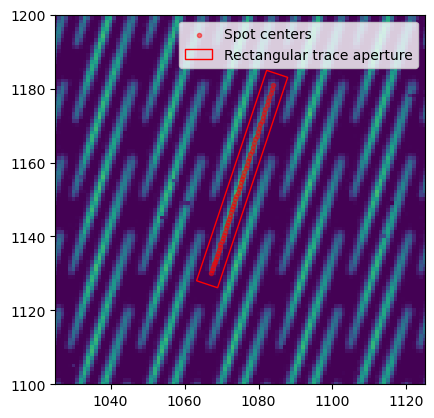

In [170]:
# Set trace coordinates and rotation angle (measured from cube dispersion angle)
trace_xcoords = res[:, 0, ti, ti]
trace_ycoords = res[:, 1, ti, ti]
rot_angle = 71.58 # rotation angle of trace CCW from horizontal axis (degrees)

## NOT necessary to do smoothing spline
# spl = make_smoothing_spline(trace_xcoords, trace_ycoords)
# xlin = np.linspace(min(trace_xcoords), max(trace_xcoords), 1000)
# ynew = spl(xlin)

# Find midpoint in x direction
span_x = max(trace_xcoords) - min(trace_xcoords)
span_y = max(trace_ycoords) - min(trace_ycoords)
span_len = span_x / np.cos( np.deg2rad(rot_angle) )
print(span_x, span_y, span_len)

midpt_x = min(trace_xcoords) + (span_x / 2.) # true midpoint of trace, NOT closest centroid to midpoint
midpt_loc = np.argmin( np.abs(trace_xcoords - midpt_x) )
midpt_y = trace_ycoords[midpt_loc] # closest centroid y-coord to  midpoint
print('midpt_loc', np.shape(midpt_loc), midpt_loc)
print('midpt_y', np.shape(midpt_y), midpt_y)
print(midpt_x, midpt_loc, midpt_y)

# Set up aperture for one trace. w > length of trace, h > spread of trace
# Traces should be 108um apart, center-to-center (plate scale 18um/px)
# Length of trace is variable by IFU mode
# 19.4 pixel separation
# 6-pixel lip all around the trace
recap = RectangularAperture((midpt_x, midpt_y), w=60., h=6., theta=np.deg2rad(rot_angle))
flux = recap.do_photometry(squish)
print('flux:', flux)

# Plot results
fig, ax = plt.subplots()
ax.imshow(squish, origin='lower', vmin=0)

ax.scatter(res[:, 0, ti, ti], res[:, 1, ti, ti], marker='.', color='r', alpha=0.5, label='Spot centers')
recap.plot(ax=ax, color='r', label='Rectangular trace aperture')

ax.set_xlim(1025,1125)
ax.set_ylim(1100,1200)
ax.legend()

In [140]:
np.nanmedian( isbg*cube[10] )

0.0

Text(0.5, 1.0, 'Median masked val: 0.0000')

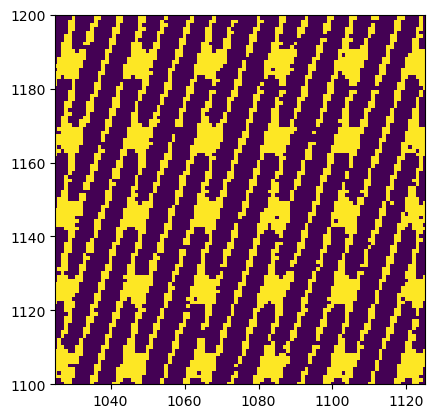

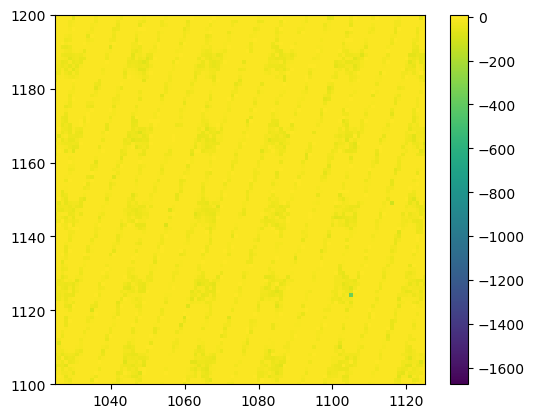

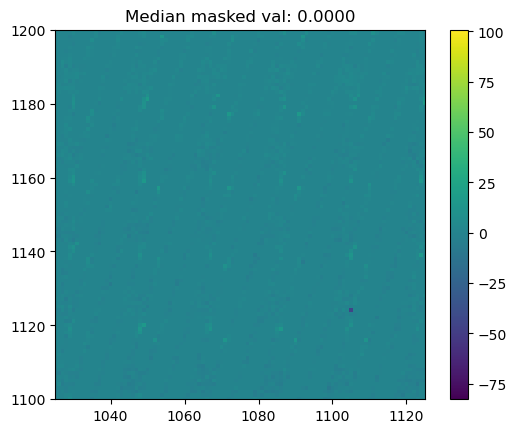

In [146]:
# Mask traces to do background subtraction on each slice of cube

# plt.hist(np.ravel(squish), bins=25)
isbg = (squish < 10.) #& (squish > -10.) # this is a little agressive, but better than other way around
plt.imshow(isbg, origin='lower')
plt.xlim(1025,1125)
plt.ylim(1100,1200)

plt.figure()
plt.imshow(isbg*squish, origin='lower')
plt.xlim(1025,1125)
plt.ylim(1100,1200)
plt.colorbar()

plt.figure()
plt.imshow(isbg*cube[10], origin='lower')
plt.xlim(1025,1125)
plt.ylim(1100,1200)
plt.colorbar()
plt.title(f'Median masked val: {np.nanmedian( isbg*cube[10] ):0.4f}')


# Check median trace-masked value for each slice of cube > they're all zeros, must already be bg-subtracted
# for i in range(np.shape(cube)[0]):
#     print(np.nanmedian( isbg*cube[i]))

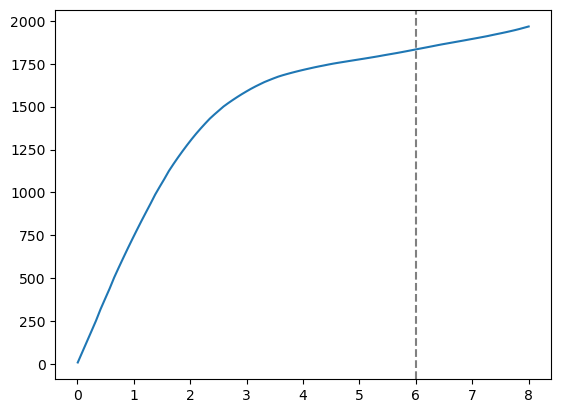

In [148]:
slit_widths = np.linspace(0.01, 8, 100) # pixels (all flux should be within 54um / 3px diameter)
fluxes = np.zeros((np.shape(cube)[0], len(slit_widths)))

for i, sw in enumerate(slit_widths):
#     for j in range(np.shape(cube)[0]):
    for j in range(15):
        
        recap = RectangularAperture((midpt_x, midpt_y), w=60., h=sw, theta=np.deg2rad(rot_angle))
        flx = recap.do_photometry( cube[j] )[0][0]
        
        fluxes[j][i] = flx
        
plt.plot( slit_widths, fluxes[10,:] )
plt.axvline(6, ls='--', color='gray')    
plt.xlabel('Slit width (px)')


In [90]:
# For a single wavelength, how much of that single monochrometer spot falls inside the rectangular 
# aperture covering the entire trace? how much falls into an adjacent spectrum?


# Enslitted energy splot: x-axis is width of slit, y-axis is total fraction of flux that falls inside slit
# (curve should go from 0% to 100%)

# Final number is the enslitted energy for 6 pixels.

# Draw limit shorter than 19 pixel separation, summed energy should plateau ~6-10 pixels.

# Figure 1: enslitted energy for single lenslet at single wavelength.
# Figure 2: heatmap showing enslitted energy within 6 pixels for every lenslet

1074.7826675765964

In [171]:
## Redo enslitted energy plot, but for set of ~10 traces (5x5) at one time

# Set trace coordinates and rotation angle (measured from cube dispersion angle)
trace_xcoords = res[:, 0, 55:60, 55:60]
trace_ycoords = res[:, 1, 55:60, 55:60]
rot_angle = 71.58 # rotation angle of trace CCW from horizontal axis (degrees)

# Find midpoint in x direction
span_x = np.max(trace_xcoords, axis=0) - np.min(trace_xcoords, axis=0)
span_y = np.max(trace_ycoords, axis=0) - np.min(trace_ycoords, axis=0)
span_len = span_x / np.cos( np.deg2rad(rot_angle) )

# print(np.shape(span_x), np.shape(span_len), span_len)

midpt_x = np.min(trace_xcoords, axis=0) + (span_x / 2.) # true midpoint of trace, NOT closest centroid to midpoint
print('midpt_x', np.shape(midpt_x), midpt_x)

midpt_loc = np.argmin( np.abs(trace_xcoords - midpt_x), axis=0 )
print('midpt_loc', np.shape(midpt_loc), midpt_loc)

midpt_y = trace_ycoords[midpt_loc] # closest centroid y-coord to  midpoint
print('midpt_y', np.shape(midpt_y), midpt_y)

midpt_x (5, 5) [[1036.98506764 1055.8685741  1074.74933337 1093.62099628 1112.47203676]
 [1037.41538033 1056.3070329  1075.1469588  1094.03921183 1112.93133051]
 [1037.82898705 1056.71865293 1075.56820149 1094.47458853 1113.35923951]
 [1038.26811478 1057.15085124 1075.97145272 1094.89883916 1113.77055812]
 [1038.73117941 1057.56647795 1076.38727306 1095.32145528 1114.21630195]]
midpt_loc (5, 5) [[30 30 30 30 30]
 [30 30 30 30 30]
 [30 30 30 30 30]
 [30 30 30 30 30]
 [30 30 30 30 30]]
midpt_y (5, 5, 5, 5) [[[[1114.79449665 1114.80735222 1114.79689756 1114.77456038
    1114.74176147]
   [1135.17722935 1135.18045247 1135.16082572 1135.14047462
    1135.13423218]
   [1155.55410661 1155.72384406 1155.52826342 1155.49999005
    1155.50145834]
   [1175.93610814 1175.9285106  1175.92787541 1175.89208107
    1175.87422722]
   [1196.33492517 1196.30957201 1196.28830518 1196.27286075
    1196.27263757]]

  [[1114.79449665 1114.80735222 1114.79689756 1114.77456038
    1114.74176147]
   [1135.17722

In [172]:
np.argmin( np.abs(trace_xcoords - midpt_x), axis=0 )

array([[30, 30, 30, 30, 30],
       [30, 30, 30, 30, 30],
       [30, 30, 30, 30, 30],
       [30, 30, 30, 30, 30],
       [30, 30, 30, 30, 30]])